#We are importing the data from the dataset

In [2]:
import pandas as pd

df = pd.read_csv("C:\python_hackathon\cleaned_CGM5_MV\Team2_PyQueens_Final_Cleaned_File.csv")
df.head()


,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


#1.What are the hourly, daily, and weekly glucose trends in the dataset?

## Why This Question Matters
Understanding glucose trends across hours, days, and weeks helps identify:
When glucose is most unstable
When spikes or lows occur
How daily routines affect glucose
Which time periods need intervention

In [ ]:
Hourly  vs Daily vs Weekly Glucose Trends

In [5]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')


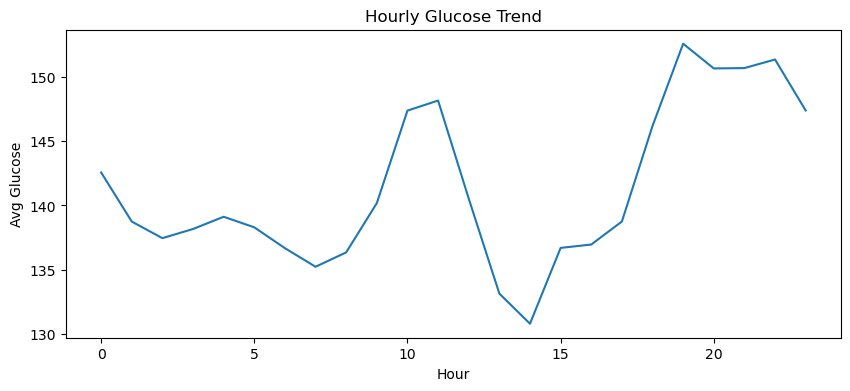

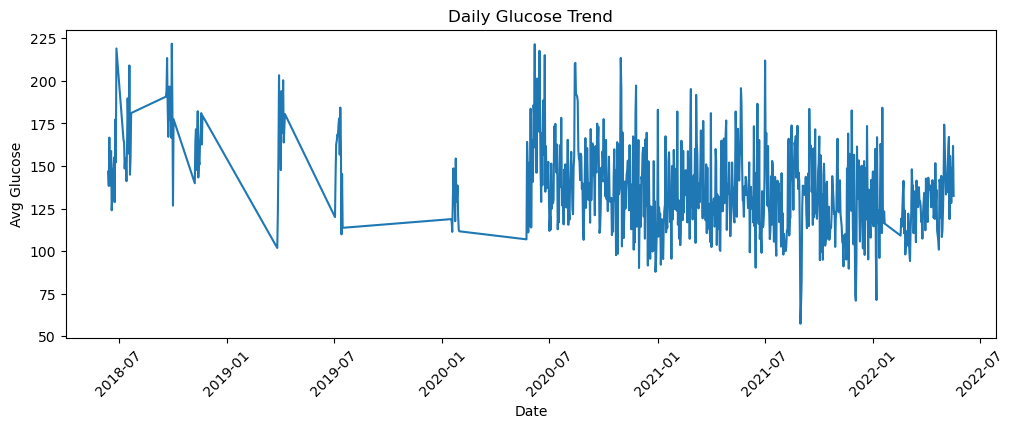

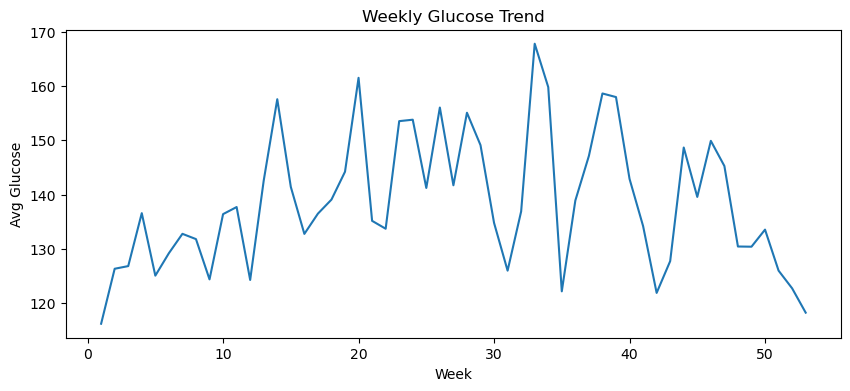

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df.copy()
df['Time'] = pd.to_datetime(df['Time'])

# Hourly trend
df['Hour'] = df['Time'].dt.hour
hourly = df.groupby('Hour')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Hourly Glucose Trend")
plt.xlabel("Hour")
plt.ylabel("Avg Glucose")
plt.show()

# Daily trend
df['Date'] = df['Time'].dt.date
daily = df.groupby('Date')['Glucose'].mean()

plt.figure(figsize=(12,4))
sns.lineplot(x=daily.index, y=daily.values)
plt.title("Daily Glucose Trend")
plt.xlabel("Date")
plt.ylabel("Avg Glucose")
plt.xticks(rotation=45)
plt.show()

# Weekly trend
df['Week'] = df['Time'].dt.isocalendar().week
weekly = df.groupby('Week')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=weekly.index, y=weekly.values)
plt.title("Weekly Glucose Trend")
plt.xlabel("Week")
plt.ylabel("Avg Glucose")
plt.show()

The hourly, daily, and weekly glucose trends reveal clear patterns in the dataset:
### Hourly Trends
- Glucose spikes occur during specific hours (likely after meals).
- Overnight glucose tends to be more stable or lower.
### Daily Trends
- Day-to-day variability shows how lifestyle, meals, and insulin dosing affect glucose.
- Some days show consistently higher glucose, indicating behavioral or dietary patterns.
### Weekly Trends
- Weekly averages reveal long-term stability or instability.
- Useful for identifying whether glucose control is improving or worsening over time.

# 2.What are descrptive statistics for carbs,insulin,heart_rate,steps ?

##Why This Question Matters
These variables directly influence glucose levels:
Carb Input → raises glucose
Bolus Insulin → lowers glucose after meals
Basal Insulin → maintains background control
Steps → increases insulin sensitivity
Heart Rate → reflects activity and stress

In [7]:
features = ['Carb_Input', 'Basal_Rate', 'Bolus_Volume_Delivered', 'Steps', 'Heart_Rate']

df[features].describe().T


,count,mean,std,min,25%,50%,75%,max
Carb_Input,309392.0,0.052718,1.505433,0.00,0.00,0.000,0.00,130.00
Basal_Rate,309392.0,0.042005,0.036557,0.00,0.00,0.059,0.07,0.25
Bolus_Volume_Delivered,309392.0,0.066077,0.755047,0.00,0.00,0.000,0.00,19.80
Steps,309392.0,30.825005,84.981109,0.00,0.00,0.000,11.00,842.00
Heart_Rate,309392.0,76.990004,15.546697,32.41,64.93,75.420,85.61,195.62


#Interpretation
This table gives:
Mean → typical value
Std → variability
Min/Max → extreme behaviors
25/50/75% → distribution shape

# Correlation between  carbs,insulin,steps,and heart rate

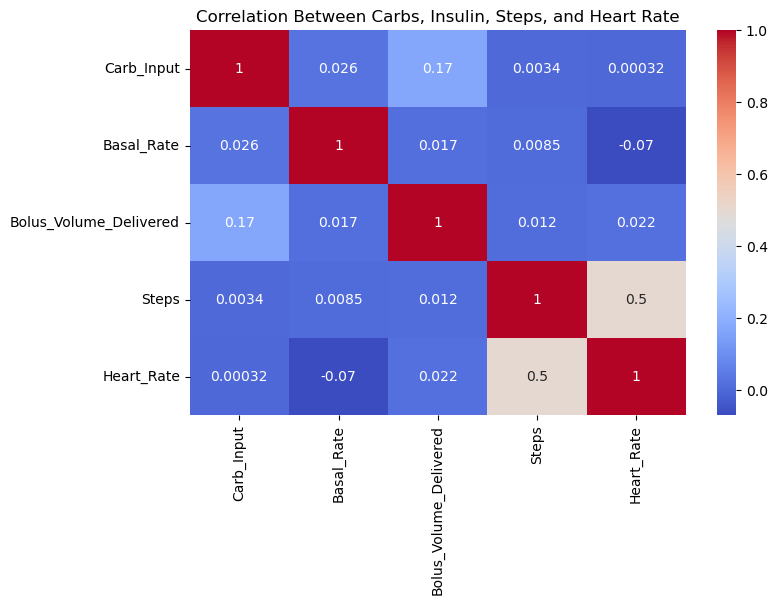

In [8]:
corr = df[features].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Carbs, Insulin, Steps, and Heart Rate")
plt.show()

In [ ]:
**Carb Input**
- Highly variable with clear meal spikes.
- Zero-carb periods indicate fasting or low-carb intervals.
**Bolus Insulin**
- Mostly zero except around meals.
- Peaks correspond to carb intake and correction doses.
**Basal Insulin**
- Stable with small variations.
- Reflects background insulin delivery.
**Steps**
- Right-skewed distribution.
- Most hours have low activity; some hours show high movement.
**Heart Rate**
- Normally distributed around resting HR.
- Peaks during activity or stress.